In [1]:
import pandas as pd
import numpy as np
import itertools
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

#### Loading ML-based prediction pre-requisite (data/algorithms) 

In [2]:
work_direc =  r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Optimal_Scheduling_Model\IO_data"
#os.chdir(work_direc)
#trained_models_direc = r"Z:\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Latest_Data_and_model"
trained_models_direc = r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Data_and_model_Nov_2025"
#os.chdir(trained_models_direc)

In [3]:
from procedure_time_and_variabiltiy_related_functions import get_prediction_required_parameters

In [4]:
procedure_time_prediction_parameters = get_prediction_required_parameters(work_direc, trained_models_direc)

In [6]:
#procedure_time_prediction_parameters = (models_types, data_model_categorisation, pred_model_related_preprocessed_data, removed_data_from_processing,
#                                                              model_input_features_all, possible_varying_data_for_patient, force_encoding_cols, trained_models_direc)

In [7]:
#procedure_time_prediction_parameters[2]

In [8]:
#procedure_time_prediction_parameters[2]

#### Testing (Planning and Real) data loading

In [5]:
df = pd.read_excel(os.path.join(work_direc,'Benefit_analysis_Oct_Nov_25/ESEOC_cases_oct_dec2025.xlsx'))
df['Actual Procedure 1 Code 1'] = df['Primary Procedure Code']
df['Actual Procedure 1 Description 1'] = df['Primary Procedure Description']
df['Hosp'] = 'ESEOC'
df['Day of the week'] = pd.to_datetime(df['Case Start Date/Time']).apply(lambda x: x.day_name())
df = df[list(procedure_time_prediction_parameters[2].columns)]

In [10]:
df.columns

Index(['Actual Procedure 1 Code 1', 'Patient ID',
       'Actual Procedure 1 Description 1', 'Planned Duration',
       'Primary Procedure Code', 'Primary Procedure Description', 'Hosp',
       'Consultant Code', 'Age group at admit', 'Gender', 'Day of the week',
       'Patient Classification', 'H4 Minutes'],
      dtype='object')

In [11]:
#[list(procedure_time_prediction_parameters[2].columns)]


In [6]:
df = df[~df['Actual Procedure 1 Code 1'].isna()].reset_index(drop=True)

#### Estimation with Model

In [7]:
from procedure_time_and_variabiltiy_related_functions import compute_surgical_time_fixed_case_sessions

In [8]:
predicted_time = compute_surgical_time_fixed_case_sessions(df, *procedure_time_prediction_parameters)

O176 not in training dataset
W596 not in training dataset
T677 not in training dataset
T678 not in training dataset
W193 not in training dataset
T671 not in training dataset
T808 not in training dataset
X118 not in training dataset
T671 not in training dataset
S523 not in training dataset
T671 not in training dataset
T649 not in training dataset
W384 not in training dataset
T677 not in training dataset
W831 not in training dataset
T773 not in training dataset
T678 not in training dataset
W021 not in training dataset
O413 not in training dataset
T671 not in training dataset
W803 not in training dataset
T677 not in training dataset
W596 not in training dataset
A734 not in training dataset
O172 not in training dataset
W431 not in training dataset
O412 not in training dataset
W384 not in training dataset
W846 not in training dataset
T699 not in training dataset
X118 not in training dataset
W247 not in training dataset
W943 not in training dataset
W852 not in training dataset
X111 not in tr

In [9]:
df_merged = df.copy()
df_merged['Model Estimation Time'] = predicted_time.values
#df_merged = df_merged.merge(predicted_time.rename('Model Estimation Time'), left_on='Patient ID', right_index=True)

In [16]:
#df_merged['Model Estimation Time'] = df_merged['Model Estimation Time'] 

In [17]:
df.shape

(1376, 13)

In [10]:
#removing data with no predicted time
df_merged = df_merged[~df_merged['Model Estimation Time'].isna()].reset_index(drop=True)
print(df_merged.shape)
#keeping only those with procedure time in between 45-300 min
df_merged = df_merged[(df_merged['H4 Minutes'] > 45) & (df_merged['H4 Minutes'] < 300)]

(1390, 14)


In [41]:
df_merged.shape

(1200, 14)

### Comparision and Analysis

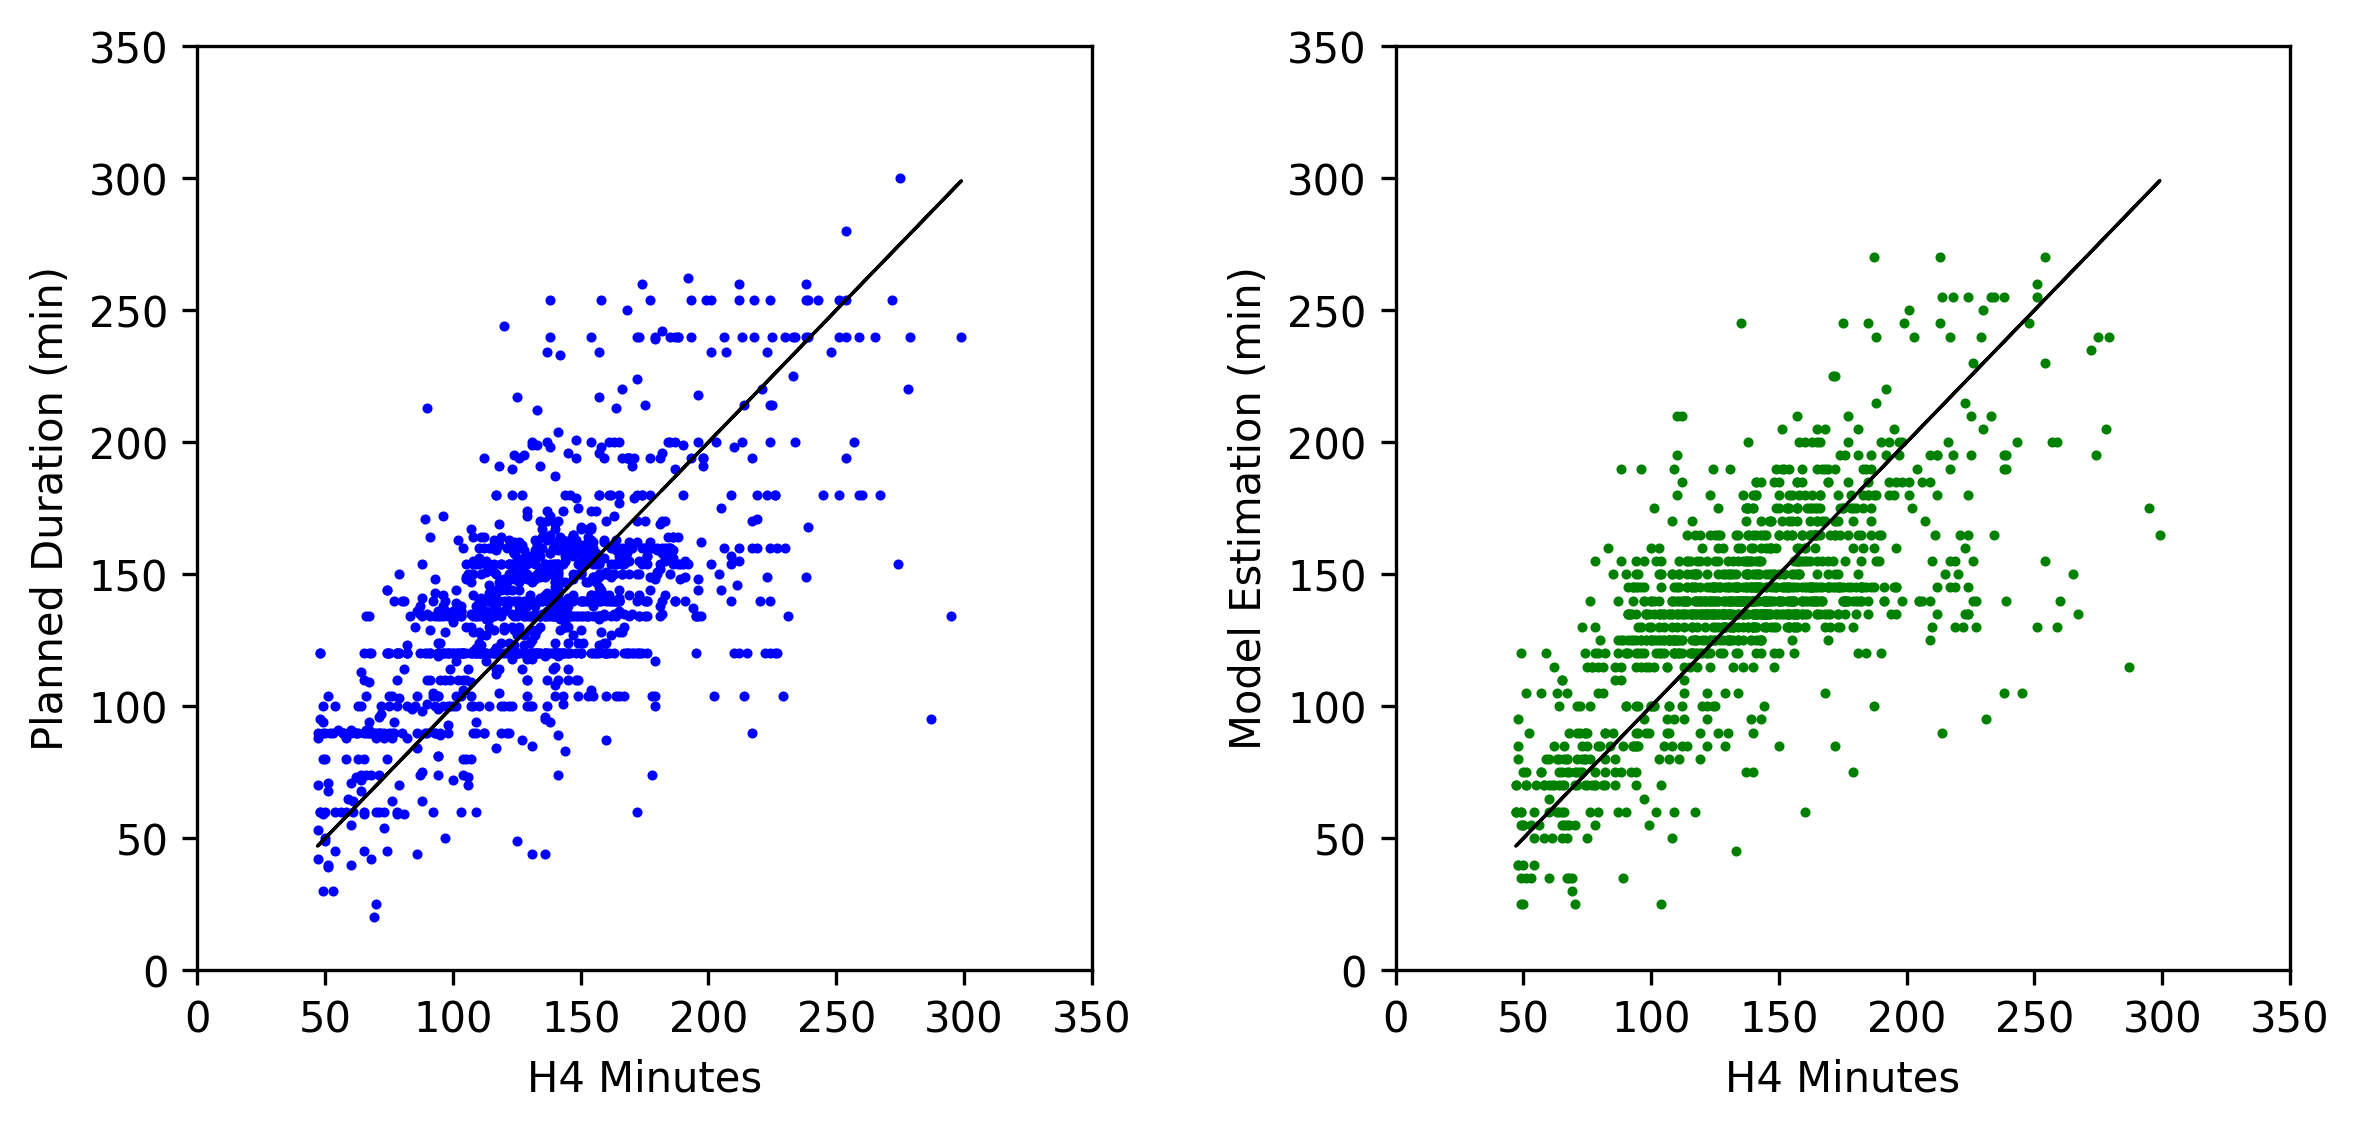

In [11]:
new_fig, axes = plt.subplots(1,2, figsize=(9, 4),  gridspec_kw={'wspace': 0.34}, dpi = 300)  
# Adjust the size as needed
#ax[0].plot()
axes[0].scatter(df_merged['H4 Minutes'],df_merged['Planned Duration'], label='Planned Duration', color='blue', s =2)
axes[0].plot(df_merged['H4 Minutes'],df_merged['H4 Minutes'], color='black', linewidth = 0.8)
#sns.lineplot(x= df_merged['H4 Minutes'], y= df_merged['H4 Minutes'], color='blue',ax = axes[0])
axes[0].set_xlim([0,350])
axes[0].set_ylim([0,350])
axes[0].set_xlabel('H4 Minutes')
axes[0].set_ylabel('Planned Duration (min)')

axes[1].scatter(df_merged['H4 Minutes'],df_merged['Model Estimation Time'], label='Model Estimated Duration', color='green', s = 2)
axes[1].plot(df_merged['H4 Minutes'],df_merged['H4 Minutes'], color='black', linewidth = 0.8)
#sns.lineplot(x= df_merged['H4 Minutes'], y= df_merged['H4 Minutes'], color='blue',ax = axes[0])
axes[1].set_xlim([0,350])
axes[1].set_ylim([0,350])
axes[1].set_xlabel('H4 Minutes')
axes[1].set_ylabel('Model Estimation (min)')
plt.show()


In [12]:
df_merged['Consultant RSE'] = (df_merged['Planned Duration']- 10- df_merged['H4 Minutes']) ** 2
df_merged['Model RSE'] = (df_merged['Model Estimation Time'] - df_merged['H4 Minutes']) ** 2

In [13]:
[np.sqrt(np.mean(df_merged['Consultant RSE'])), np.sqrt(np.mean(df_merged['Model RSE']))]

[35.734666164295795, 32.782551032125504]

In [14]:
[np.sqrt(np.mean(df_merged['Consultant RSE'])), np.sqrt(np.mean(df_merged['Model RSE']))]

[35.734666164295795, 32.782551032125504]

In [15]:
# Calculate Percentage Error for each row
df_merged['Consultant % Error'] = np.abs((df_merged['Planned Duration'] -10- df_merged['H4 Minutes']) / df_merged['H4 Minutes']) * 100
df_merged['Model % Error'] = np.abs((df_merged['Model Estimation Time'] - df_merged['H4 Minutes']) / df_merged['H4 Minutes']) * 100

In [16]:
#len(df_merged)
[np.mean(df_merged['Consultant % Error']), np.mean(df_merged['Model % Error'])]

[20.48096669792651, 18.836740129831863]

In [17]:
[np.mean(df_merged['Consultant % Error']), np.mean(df_merged['Model % Error'])]

[20.48096669792651, 18.836740129831863]

### Comparative Plots

#### Procedure wise comparision

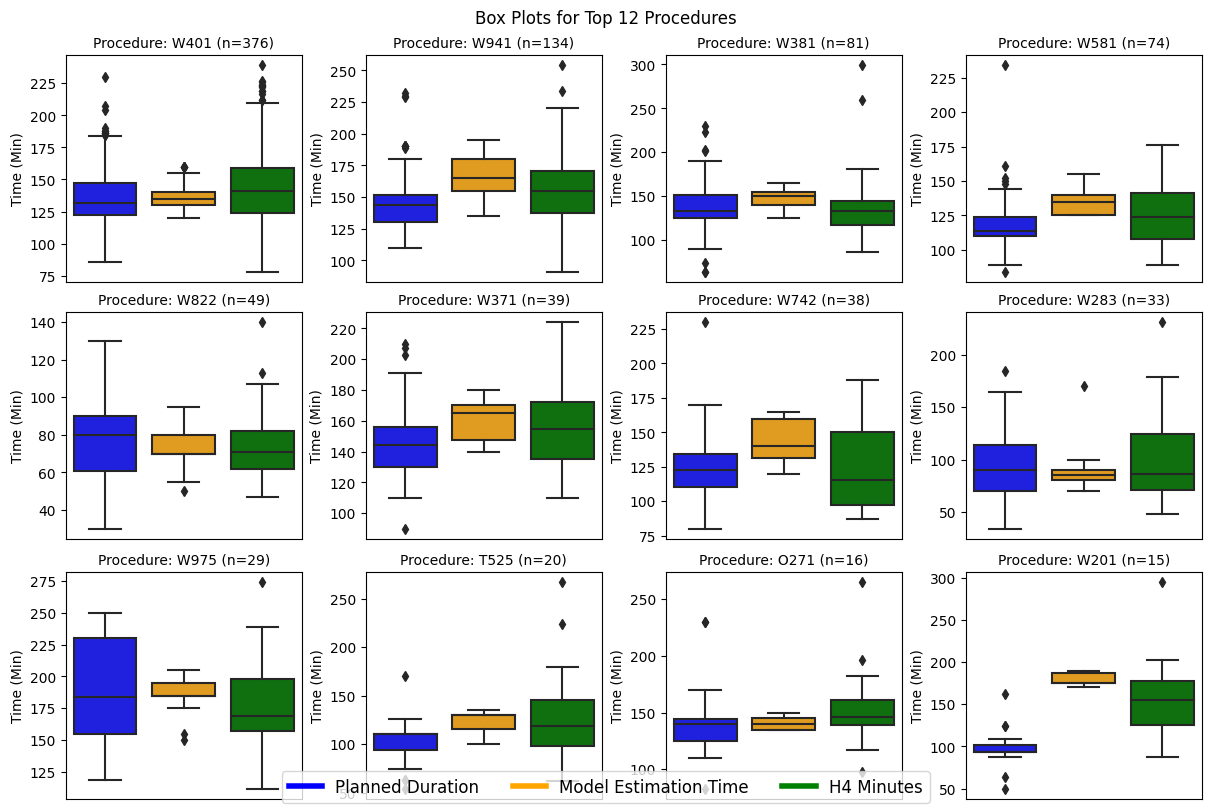

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df_merged['Planned Duration']  = df_merged['Planned Duration'] - 10
# Identify top 15 procedures (based on frequency)
top_procedures = df_merged['Actual Procedure 1 Code 1'].value_counts().head(12).index

# Filter DataFrame for top procedures
df_top = df_merged[df_merged['Actual Procedure 1 Code 1'].isin(top_procedures)]

# Melt the DataFrame for easier plotting
df_melted = df_top.melt(
    id_vars=['Actual Procedure 1 Code 1'],
    value_vars=['Planned Duration', 'Model Estimation Time', 'H4 Minutes'],
    var_name='TimeType',
    value_name='Value'
)

# Set up the plot
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

palette = {'Planned Duration':'blue', 'Model Estimation Time':'orange', 'H4 Minutes':'green'}

# Plot box plots for each procedure
for i, procedure in enumerate(top_procedures):
    ax = axes[i]
    procedure_data = df_melted[df_melted['Actual Procedure 1 Code 1'] == procedure]
    sns.boxplot(
        data= procedure_data,
        x='TimeType',
        y='Value',
        ax=ax,
        palette=palette
    )
    
    ax.set_title(f'Procedure: {procedure} (n={int(len(procedure_data)/3)})', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Turn off x-ticks
    ax.set_ylabel('Time (Min)')

# Add a single legend to the first subplot
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in palette.values()]
labels = palette.keys()
fig.legend(handles, palette.keys(), loc='lower center', ncol=3, title='', fontsize=12)


# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Box Plots for Top {len(top_procedures)} Procedures', fontsize=12)

plt.savefig(os.path.join(work_direc,'Benefit_analysis_Oct_Nov_25/Individaul Procedure wise performance.png'), dpi = 300)

plt.show()


In [19]:
# Identify top 15 procedures (based on frequency)
top_procedures = df_merged['Actual Procedure 1 Code 1'].value_counts().head(12).index

# Filter DataFrame for top procedures
df_top = df_merged[df_merged['Actual Procedure 1 Code 1'].isin(top_procedures)]

# Melt the DataFrame for easier plotting
rmse_array = np.zeros((len(top_procedures),2))
# Plot box plots for each procedure
for i, procedure in enumerate(top_procedures):
    #rmse_array[i,0] = procedure
    procedure_data = df_top[df_top['Actual Procedure 1 Code 1'] == procedure]
    rmse_array[i,0] = np.sqrt(np.mean((procedure_data['Planned Duration'] -10 - procedure_data['H4 Minutes']) ** 2))
    rmse_array[i,0] = round(rmse_array[i,0],2)
    rmse_array[i,1] = np.sqrt(np.mean((procedure_data['Model Estimation Time'] - procedure_data['H4 Minutes']) ** 2))
    rmse_array[i,1] = round(rmse_array[i,1],2)


In [20]:
pd.DataFrame(rmse_array, columns = ['Planned vs Real', 'Model est vs real'], index = top_procedures)

,Planned vs Real,Model est vs real
Actual Procedure 1 Code 1,,
W401,35.20,26.99
W941,34.76,27.79
W381,34.73,33.22
W581,33.06,23.12
W822,20.61,16.50
W371,38.22,24.68
W742,27.98,29.66
W283,47.81,40.45
W975,45.37,33.06


#### Scatter plot

In [21]:
df_merged_sorted_by_time_value = df_merged.sort_values(by = ['H4 Minutes']).reset_index(drop=True)
df_merged_sorted_by_time_value = df_merged_sorted_by_time_value[df_merged_sorted_by_time_value['H4 Minutes'] > 10]

In [32]:
df_merged_sorted_by_time_value

,Actual Procedure 1 Code 1,Patient ID,Actual Procedure 1 Description 1,Planned Duration,Primary Procedure Code,Primary Procedure Description,Hosp,Consultant Code,Age group at admit,Gender,Day of the week,Patient Classification,H4 Minutes,Model Estimation Time,Consultant RSE,Model RSE,Consultant % Error,Model % Error
0,T702,20935930,Tenotomy,60,T702,Tenotomy,ESEOC,C4752583,Above80,Female,Monday,Day case admission,47,60.0,256,169.0,32.978723,27.659574
1,A611,22171541,Primary neurolysis of peripheral nerve,32,A611,Primary neurolysis of peripheral nerve,ESEOC,C4354404,31to50,Male,Monday,Day case admission,47,60.0,144,169.0,26.595745,27.659574
2,T591,21073031,Excision of ganglion of wrist,43,T591,Excision of ganglion of wrist,ESEOC,C7139584,31to50,Male,Monday,Day case admission,47,70.0,1,529.0,3.191489,48.93617
3,W822,21231852,Arthroscopy of knee joint,78,W822,Arthroscopy of knee joint,ESEOC,C4537935,51to60,Female,Wednesday,Day case admission,47,70.0,1156,529.0,71.276596,48.93617
4,W851,22102821,Arthroscopy and biopsy of knee,80,W851,Arthroscopy and biopsy of knee,ESEOC,C2983125,31to50,Female,Monday,Day case admission,47,60.0,1296,169.0,75.531915,27.659574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,W403,21379467,Revision of knee replacement,210,W403,Revision of knee replacement,ESEOC,C6074474,71to80,Male,Tuesday,Ordinary Admission,278,205.0,4225,5329.0,23.561151,26.258993
1196,W041,21745832,Complex reconstruction of hindfoot,230,W041,Complex reconstruction of hindfoot,ESEOC,C4641678,61to70,Male,Friday,Ordinary Admission,279,240.0,2116,1521.0,16.666667,13.978495
1197,W593,20461332,Primary fusion of joint,85,W593,Primary fusion of joint,ESEOC,C4626246,51to60,Female,Friday,Day case admission,287,115.0,39601,29584.0,69.512195,59.930314
1198,W201,21001423,Open reduction of fracture of radius with inte...,124,W201,Open reduction of fracture of radius with inte...,ESEOC,C4752583,51to60,Male,Friday,Ordinary Admission,295,175.0,28224,14400.0,57.118644,40.677966


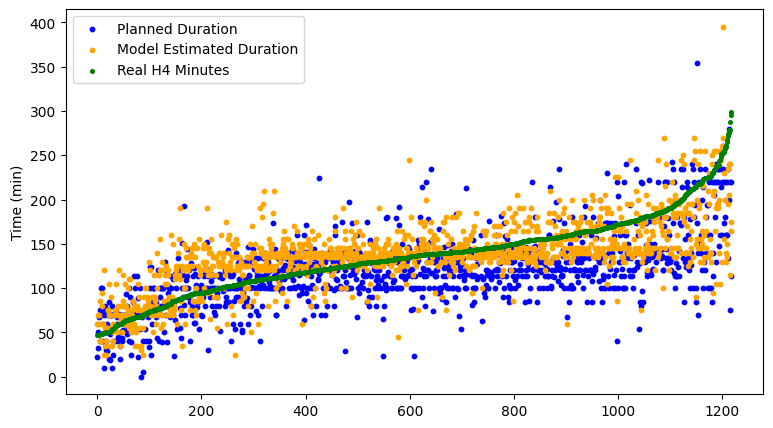

In [22]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.scatter(df_merged_sorted_by_time_value['Patient ID'].index,df_merged_sorted_by_time_value['Planned Duration']-10, label='Planned Duration', color='blue', s=10)
ax1.scatter(df_merged_sorted_by_time_value['Patient ID'].index, df_merged_sorted_by_time_value['Model Estimation Time'], label='Model Estimated Duration', color='orange', s = 10)
ax1.scatter(df_merged_sorted_by_time_value['Patient ID'].index, df_merged_sorted_by_time_value['H4 Minutes'], label='Real H4 Minutes', color='green', s = 7)

ax1.set_ylabel('Time (min)')
#ax1.set_xlabel('Patient ID')
ax1.legend(loc='upper left')

plt.savefig(os.path.join(work_direc,'Benefit_analysis_Oct_Nov_25/Case wise_time_estimation performance.png'), dpi = 300)

plt.show()

In [ ]:
fig, axes = plt.subfig